In [1]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm


from IPPy import operators
from IPPy.solvers import ChambollePockTpVConstrained
from IPPy.utilities import normalize, save_image
from IPPy.utilities.metrics import PSNR, SSIM, RE

from utils.data_utils import load_normalized_image

# Input
TEST_DIR = Path("../dataset_resized/test_resized")
SINOGRAMS_DIR = Path("../sinograms")

# Output ricostruzioni TV
TV_DIR = Path("../reconstructions/tv")
TV_DIR.mkdir(parents=True, exist_ok=True)

# Stessa configurazione angolare usata in 02_synogram_generation,
# necessaria per ricostruire lo stesso operatore K con cui e' stato generato il sinogramma
ANGLE_CONFIGS = {
    90: np.linspace(-45, 45, 90),
    45: np.linspace(-45, 45, 45),
    30: np.linspace(-30, 30, 32)[1:-1],
    15: np.linspace(-30, 30, 17)[1:-1],
}

NOISE_LEVEL = 0.005
IMG_SIZE = (256, 256)

# Prova su una singola configurazione angolare, poi si estende alle altre
N_ANGLES = 90


K = operators.CTProjector(
    img_shape=IMG_SIZE,
    angles=np.deg2rad(ANGLE_CONFIGS[N_ANGLES]),
    geometry="parallel",
    force_cpu=True,
)


Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP


In [2]:
# ============================================================
# Hyperparameter tuning: scelta di lambda_tv per ciascuna
# configurazione angolare, su un campione di VALIDATION
# ============================================================

VALIDATION_DIR = Path("../dataset_resized/validation_resized")
N_VAL_SAMPLES = 12
LAMBDA_CANDIDATES = [1e-3, 3e-3, 1e-2, 3e-2, 5e-2, 1e-1, 2e-1, 5e-1]
TUNING_MAXITER = 150
PSNR_WEIGHT = 0.5

PROJECTORS = {
    n_angles: operators.CTProjector(
        img_shape=IMG_SIZE,
        angles=np.deg2rad(angles),
        geometry="parallel",
        force_cpu=True,
    )
    for n_angles, angles in ANGLE_CONFIGS.items()
}

best_lambda_per_config = {}
tuning_results = {}

for n_angles, K_config in PROJECTORS.items():
    print(f"\n=== Tuning lambda per configurazione: {n_angles} angoli ===")

    # Creato UNA SOLA VOLTA per configurazione, non ad ogni immagine/lambda
    solver = ChambollePockTpVConstrained(K_config)

    val_sino_paths = sorted((SINOGRAMS_DIR / "validation" / str(n_angles)).rglob("*.npy"))[:N_VAL_SAMPLES]

    # Pre-carichiamo anche sinogrammi e ground truth UNA volta sola,
    # invece di ricaricarli da disco per ogni lambda candidato
    cached_data = []
    for sino_path in val_sino_paths:
        rel_path = sino_path.relative_to(SINOGRAMS_DIR / "validation" / str(n_angles))
        gt_path = (VALIDATION_DIR / rel_path).with_suffix(".png")

        sinogram = np.load(sino_path)
        y_delta = torch.from_numpy(sinogram).float().unsqueeze(0).unsqueeze(0)

        gt = load_normalized_image(gt_path)
        x_true = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)

        epsilon = NOISE_LEVEL * torch.norm(y_delta)

        cached_data.append((y_delta, x_true, epsilon))

    results = []
    for lambda_tv in tqdm(LAMBDA_CANDIDATES, desc=f"[{n_angles} angoli] lambda candidati"):
        psnr_list, ssim_list = [], []

        for y_delta, x_true, epsilon in tqdm(cached_data, desc=f"  lambda={lambda_tv}", leave=False):
            x_sol, info = solver(
                y_delta,
                epsilon=epsilon,
                lmbda=lambda_tv,
                x_true=x_true,
                starting_point=torch.zeros_like(x_true),
                maxiter=TUNING_MAXITER,
                p=1,
                verbose=False,
            )

            psnr_list.append(info["PSNR"][-1].item())
            ssim_list.append(info["SSIM"][-1].item())

        psnr_mean = np.mean(psnr_list)
        ssim_mean = np.mean(ssim_list)
        results.append((lambda_tv, psnr_mean, ssim_mean))
        print(f"  lambda={lambda_tv:<8}  PSNR medio={psnr_mean:.2f} dB  SSIM medio={ssim_mean:.4f}")

    psnr_values = np.array([r[1] for r in results])
    ssim_values = np.array([r[2] for r in results])

    psnr_norm = (psnr_values - psnr_values.min()) / (psnr_values.max() - psnr_values.min() + 1e-12)
    ssim_norm = (ssim_values - ssim_values.min()) / (ssim_values.max() - ssim_values.min() + 1e-12)

    combined = PSNR_WEIGHT * psnr_norm + (1 - PSNR_WEIGHT) * ssim_norm

    best_psnr_idx = int(np.argmax(psnr_values))
    best_ssim_idx = int(np.argmax(ssim_values))
    best_combined_idx = int(np.argmax(combined))

    print(f"  Migliore per PSNR:     lambda={results[best_psnr_idx][0]}")
    print(f"  Migliore per SSIM:     lambda={results[best_ssim_idx][0]}")
    print(f"  Migliore combinato:    lambda={results[best_combined_idx][0]}  "
          f"(PSNR={results[best_combined_idx][1]:.2f}, SSIM={results[best_combined_idx][2]:.4f})")

    best_lambda_per_config[n_angles] = results[best_combined_idx][0]
    tuning_results[n_angles] = results

print("\n=== Riepilogo finale (lambda scelto per configurazione) ===")
print(best_lambda_per_config)

# ---- Salvataggio su disco, per non perdere il risultato riavviando il notebook ----
import json

TUNING_DIR = Path("../tuning_results")
TUNING_DIR.mkdir(parents=True, exist_ok=True)

with open(TUNING_DIR / "best_lambda_tv.json", "w") as f:
    json.dump(best_lambda_per_config, f, indent=2)

print("Salvato in:", TUNING_DIR / "best_lambda_tv.json")

Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP

=== Tuning lambda per configurazione: 90 angoli ===


[90 angoli] lambda candidati:   0%|          | 0/8 [00:00<?, ?it/s]c:\Users\danie\Documents\GitHub\limited-angle-ct-reconstruction\.venv\Lib\site-packages\IPPy\solvers.py:127: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  nu = math.sqrt(
[90 angoli] lambda candidati:  12%|█▎        | 1/8 [04:08<28:57, 248.24s/it]

  lambda=0.001     PSNR medio=21.38 dB  SSIM medio=0.6185


[90 angoli] lambda candidati:  25%|██▌       | 2/8 [08:51<26:52, 268.76s/it]

  lambda=0.003     PSNR medio=21.55 dB  SSIM medio=0.6391


...

  lambda=0.1       PSNR medio=19.52 dB  SSIM medio=0.5433


[15 angoli] lambda candidati:  88%|████████▊ | 7/8 [08:19<01:12, 72.74s/it]

  lambda=0.2       PSNR medio=19.38 dB  SSIM medio=0.5349


[15 angoli] lambda candidati: 100%|██████████| 8/8 [09:32<00:00, 71.51s/it]

  lambda=0.5       PSNR medio=19.10 dB  SSIM medio=0.5178
  Migliore per PSNR:     lambda=0.01
  Migliore per SSIM:     lambda=0.03
  Migliore combinato:    lambda=0.03  (PSNR=19.63, SSIM=0.5483)

=== Riepilogo finale (lambda scelto per configurazione) ===
{90: 0.05, 45: 0.05, 30: 0.03, 15: 0.03}
Salvato in: ..\tuning_results\best_lambda_tv.json


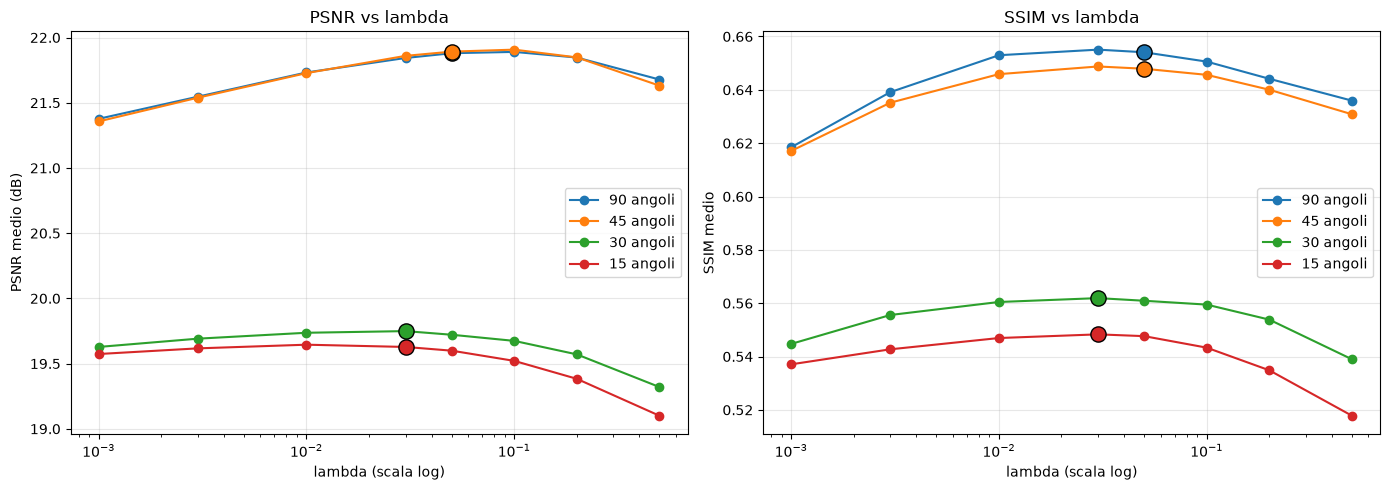

Grafico salvato in: ..\tuning_results\lambda_tuning_curves.png


In [3]:
# ============================================================
# Grafico: PSNR e SSIM medi vs lambda, per ciascuna configurazione
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for n_angles, results in tuning_results.items():
    lambdas = [r[0] for r in results]
    psnr_vals = [r[1] for r in results]
    ssim_vals = [r[2] for r in results]

    axs[0].plot(lambdas, psnr_vals, marker="o", label=f"{n_angles} angoli")
    axs[1].plot(lambdas, ssim_vals, marker="o", label=f"{n_angles} angoli")

    # evidenzia il punto scelto come migliore
    best_lambda = best_lambda_per_config[n_angles]
    best_idx = lambdas.index(best_lambda)
    axs[0].scatter(best_lambda, psnr_vals[best_idx], s=120, edgecolor="black", zorder=5)
    axs[1].scatter(best_lambda, ssim_vals[best_idx], s=120, edgecolor="black", zorder=5)

axs[0].set_xscale("log")
axs[0].set_xlabel("lambda (scala log)")
axs[0].set_ylabel("PSNR medio (dB)")
axs[0].set_title("PSNR vs lambda")
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].set_xscale("log")
axs[1].set_xlabel("lambda (scala log)")
axs[1].set_ylabel("SSIM medio")
axs[1].set_title("SSIM vs lambda")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(TUNING_DIR / "lambda_tuning_curves.png", dpi=150)
plt.show()

print(f"Grafico salvato in: {TUNING_DIR / 'lambda_tuning_curves.png'}")


=== Curve di convergenza per 90 angoli (lambda=0.05) ===


  PSNR massimo a iterazione 400 (PSNR=22.74 dB)
  SSIM massimo a iterazione 400 (SSIM=0.6852)

=== Curve di convergenza per 45 angoli (lambda=0.05) ===


  PSNR massimo a iterazione 400 (PSNR=22.65 dB)
  SSIM massimo a iterazione 400 (SSIM=0.6800)

=== Curve di convergenza per 30 angoli (lambda=0.03) ===


  PSNR massimo a iterazione 400 (PSNR=20.19 dB)
  SSIM massimo a iterazione 400 (SSIM=0.5848)

=== Curve di convergenza per 15 angoli (lambda=0.03) ===


  PSNR massimo a iterazione 400 (PSNR=19.96 dB)
  SSIM massimo a iterazione 400 (SSIM=0.5655)

=== Riepilogo maxiter scelto per configurazione ===
{90: 400, 45: 400, 30: 400, 15: 400}


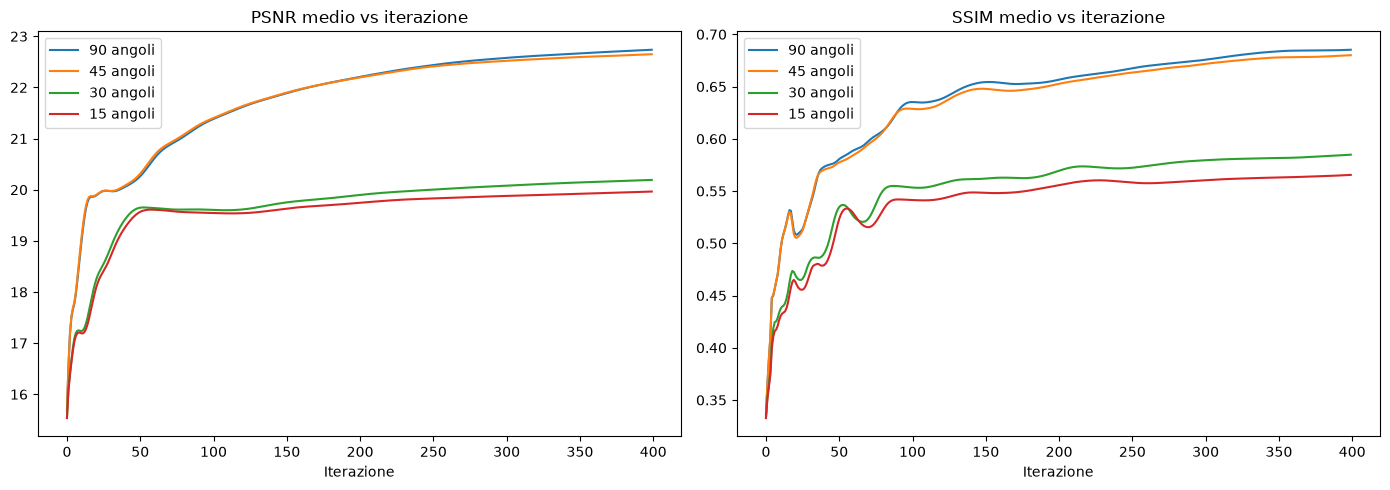

Salvato in: ..\tuning_results\best_maxiter.json


In [4]:
# ============================================================
# Scelta del numero di iterazioni (maxiter): un unico run lungo
# per configurazione, usando il lambda ottimale trovato prima,
# guardando dove la curva PSNR/SSIM si stabilizza
# ============================================================

LONG_RUN_MAXITER = 400   # generoso, così vediamo l'intero comportamento

convergence_curves = {}   # n_angles -> (psnr_medio_per_iter, ssim_medio_per_iter)
best_maxiter_per_config = {}

for n_angles, K_config in PROJECTORS.items():
    lambda_tv = best_lambda_per_config[n_angles]   # riusa il lambda scelto prima
    solver = ChambollePockTpVConstrained(K_config)  # creato UNA VOLTA per configurazione
    print(f"\n=== Curve di convergenza per {n_angles} angoli (lambda={lambda_tv}) ===")

    val_sino_paths = sorted((SINOGRAMS_DIR / "validation" / str(n_angles)).rglob("*.npy"))[:N_VAL_SAMPLES]

    psnr_curves, ssim_curves = [], []

    for sino_path in tqdm(val_sino_paths, desc=f"[{n_angles} angoli]", leave=False):
        rel_path = sino_path.relative_to(SINOGRAMS_DIR / "validation" / str(n_angles))
        gt_path = (VALIDATION_DIR / rel_path).with_suffix(".png")

        sinogram = np.load(sino_path)
        y_delta = torch.from_numpy(sinogram).float().unsqueeze(0).unsqueeze(0)

        gt = load_normalized_image(gt_path)
        x_true = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)

        epsilon = NOISE_LEVEL * torch.norm(y_delta)

        _, info = solver(
            y_delta,
            epsilon=epsilon,
            lmbda=lambda_tv,
            x_true=x_true,
            starting_point=torch.zeros_like(x_true),
            maxiter=LONG_RUN_MAXITER,
            p=1,
            verbose=False,
        )

        psnr_curves.append(info["PSNR"].detach().numpy())
        ssim_curves.append(info["SSIM"].detach().numpy())

    # media delle curve su tutte le immagini del campione
    psnr_mean_curve = np.mean(psnr_curves, axis=0)
    ssim_mean_curve = np.mean(ssim_curves, axis=0)
    convergence_curves[n_angles] = (psnr_mean_curve, ssim_mean_curve)

    # trova l'iterazione in cui il PSNR medio raggiunge il massimo
    best_iter_psnr = int(np.argmax(psnr_mean_curve)) + 1
    best_iter_ssim = int(np.argmax(ssim_mean_curve)) + 1
    print(f"  PSNR massimo a iterazione {best_iter_psnr} (PSNR={psnr_mean_curve.max():.2f} dB)")
    print(f"  SSIM massimo a iterazione {best_iter_ssim} (SSIM={ssim_mean_curve.max():.4f})")

    # scelta finale: la più "conservativa" delle due (cattura entrambi i picchi)
    best_maxiter_per_config[n_angles] = max(best_iter_psnr, best_iter_ssim)

print("\n=== Riepilogo maxiter scelto per configurazione ===")
print(best_maxiter_per_config)

# ---- Grafico riassuntivo, una curva per configurazione ----
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for n_angles, (psnr_curve, ssim_curve) in convergence_curves.items():
    axs[0].plot(psnr_curve, label=f"{n_angles} angoli")
    axs[1].plot(ssim_curve, label=f"{n_angles} angoli")

axs[0].set_title("PSNR medio vs iterazione")
axs[0].set_xlabel("Iterazione")
axs[0].legend()

axs[1].set_title("SSIM medio vs iterazione")
axs[1].set_xlabel("Iterazione")
axs[1].legend()

plt.tight_layout()
plt.savefig(TUNING_DIR / "maxiter_convergence_curves.png", dpi=150)
plt.show()

# ---- Salvataggio su disco ----
with open(TUNING_DIR / "best_maxiter.json", "w") as f:
    json.dump(best_maxiter_per_config, f, indent=2)

print("Salvato in:", TUNING_DIR / "best_maxiter.json")